<a href="https://colab.research.google.com/github/vikrampal12345/Machine_learning/blob/main/12_Missing_Everytype_DataHandling/6_Missing_indicator_Random_sample_imputation_Handling_missing_data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Imputation

1. Preserves the variance of the Variable(But why?)

2. Memory heavy for deployment, as we need to store the original training set to extract values from and replace the NA in coming observations

3. Well suited for linear models as it does not distort the distribution, regardless of the % of NA..

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df1 = sns.load_dataset('titanic')
df = df1.iloc[:,[0,3,6]]
df.head()

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [ ]:
df.isnull().mean() * 100

,0
survived,0.00000
age,19.86532
fare,0.00000


In [ ]:
x = df.drop('survived', axis=1)
y = df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

X_train.shape, X_test.shape

((712, 2), (179, 2))

In [ ]:
X_train['age_imputed'] = X_train['age']
X_test['age_imputed'] = X_test['age']

In [ ]:
X_train.sample(5)

,age,fare,age_imputed
108,38.0,7.8958,38.0
585,18.0,79.6500,18.0
27,19.0,263.0000,19.0
364,NaN,15.5000,NaN
770,24.0,9.5000,24.0


In [ ]:
X_train['age_imputed'][X_train['age_imputed'].isnull()]   # null value extract

,age_imputed
77,NaN
868,NaN
334,NaN
295,NaN
792,NaN
...,...
674,NaN
466,NaN
584,NaN
527,NaN


In [ ]:
# extract the random number from the data
# the numbers are equal to the total null

X_train['age'].dropna().sample(X_train['age'].isnull().sum()).values

array([33.  , 16.  , 53.  , 70.5 , 58.  , 19.  , 43.  , 31.  , 19.  ,
       36.  , 28.  , 29.  , 28.  , 17.  , 26.  , 19.  , 42.  , 29.  ,
       35.  , 24.  , 24.  , 44.  , 15.  , 16.  , 58.  , 31.  , 32.  ,
       25.  ,  9.  , 43.  , 56.  , 14.5 , 42.  , 32.5 , 21.  , 19.  ,
       48.  ,  6.  , 45.  , 25.  , 26.  , 22.  , 21.  ,  2.  ,  2.  ,
       23.  , 30.  , 27.  , 49.  , 16.  , 18.  , 16.  , 18.  , 14.  ,
       34.  ,  1.  , 16.  , 18.  , 50.  , 39.  , 61.  ,  4.  , 33.  ,
       36.  , 52.  , 45.  , 36.  , 32.  , 40.  , 26.  , 19.  , 18.  ,
       59.  , 71.  , 24.  , 35.  , 39.  , 21.  , 36.  , 18.  , 30.  ,
       32.  , 28.5 , 33.  , 18.  , 23.  , 26.  , 30.  , 37.  ,  2.  ,
       13.  , 37.  , 21.  , 21.  , 32.  , 47.  , 43.  , 51.  , 46.  ,
       26.  , 21.  , 17.  , 46.  ,  4.  , 24.  , 16.  , 22.  ,  0.83,
        3.  , 31.  , 47.  , 35.  , 27.  , 30.5 , 16.  , 32.  , 37.  ,
        4.  , 31.  ,  8.  ,  8.  , 65.  , 30.  , 36.  , 20.  , 29.  ,
       16.  , 32.  ,

In [ ]:
X_train['age_imputed'][X_train['age_imputed'].isnull()] = X_train['age'].dropna().sample(X_train['age'].isnull().sum()).values

X_test['age_imputed'][X_test['age_imputed'].isnull()] = X_test['age'].dropna().sample(X_test['age'].isnull().sum()).values

/tmp/ipykernel_2903/652541823.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['age_imputed'][X_train['age_imputed'].isnull()] = X_train['age'].dropna().sample(X_train['age'].isnull().sum()).values
/tmp/ipykernel_2903/652541823.py

In [ ]:
X_train.isnull().mean() * 100

,0
age,20.786517
fare,0.000000
age_imputed,0.000000


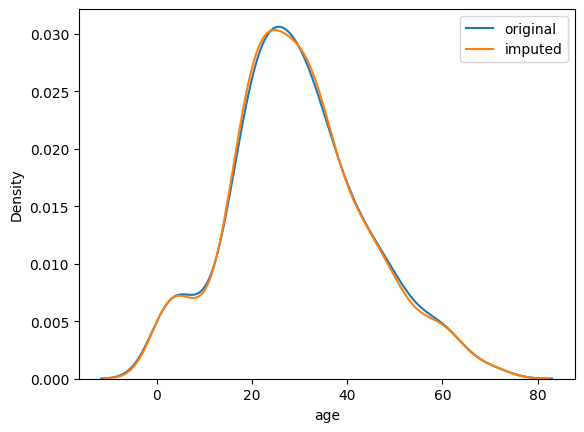

In [ ]:
sns.kdeplot(X_train['age'], label='original')
sns.kdeplot(X_train['age_imputed'], label='imputed')

plt.legend()
plt.show()

In [ ]:
print('Original variable variance: ', X_train['age'].var())
print('Variance after random imputation: ', X_train['age_imputed'].var())

Original variable variance:  204.3495133904614
Variance after random imputation:  201.74975701871858


In [ ]:
X_train[['fare', 'age', 'age_imputed']].cov()

,fare,age,age_imputed
fare,2368.246832,71.512440,65.668568
age,71.512440,204.349513,204.349513
age_imputed,65.668568,204.349513,201.749757


<Axes: >

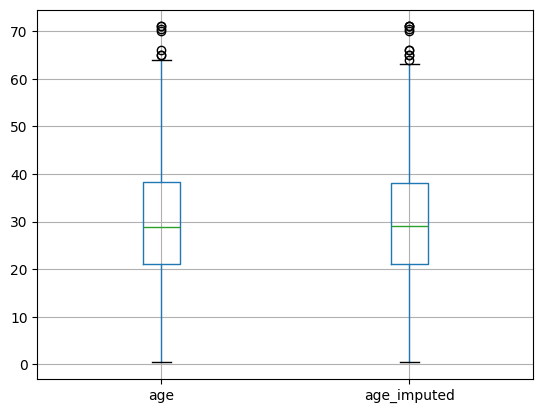

In [ ]:
X_train[['age', 'age_imputed']].boxplot()

In [ ]:
# for the production when user put the fare and then the random age comes everytime
# then the output is different everytime so for handle do this
# check and fix it

sampled_value = X_train['age'].dropna().sample(1, random_state=int(observation['fare']))

NameError: name 'observation' is not defined

In [ ]:
data = pd.read_csv('/content/house-train (1).csv', usecols = ['GarageQual', 'FireplaceQu', 'SalePrice'])

In [ ]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [ ]:
data.isnull().mean() * 100

,0
FireplaceQu,47.260274
GarageQual,5.547945
SalePrice,0.000000


In [ ]:
x = data
y = data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [ ]:
X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']


In [ ]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1257,NaN,NaN,99900,NaN,NaN
426,TA,TA,275000,TA,TA
146,NaN,Fa,105000,Fa,NaN
600,Gd,TA,275000,TA,Gd
243,TA,TA,120000,TA,TA


In [ ]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()]

,GarageQual_imputed
127,NaN
99,NaN
921,NaN
1179,NaN
1143,NaN
...,...
434,NaN
942,NaN
1326,NaN
1349,NaN


In [ ]:
X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values

array(['Gd', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA',
       'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'Fa', 'TA', 'TA',
       'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA',
       'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA',
       'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA',
       'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA', 'TA'],
      dtype=object)

In [ ]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()]  = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values

X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()]  = X_test['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()]  = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values

X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()]  = X_test['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

/tmp/ipykernel_2903/4105367511.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()]  = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
/t

In [ ]:
X_train

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
455,TA,TA,175500,TA,TA
863,NaN,TA,132500,TA,TA
504,Fa,TA,147000,TA,Fa
1413,Gd,TA,257000,TA,Gd
1389,Gd,TA,131000,TA,Gd
...,...,...,...,...,...
466,Po,TA,167000,TA,Po
299,Gd,TA,158500,TA,Gd
493,Fa,TA,155000,TA,Fa
527,Gd,TA,446261,TA,Gd


In [ ]:
temp = pd.concat([
    X_train['GarageQual'].value_counts() / len(X_train['GarageQual'].dropna()),
    X_train['GarageQual_imputed'].value_counts() / len(X_train)
], axis = 1)

temp.columns = ['Original', 'imputed']

In [ ]:
temp

,Original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.035959
Gd,0.009973,0.009418
Po,0.000907,0.001712
Ex,0.000907,0.000856


In [74]:
temp1 = pd.concat([
    X_train['FireplaceQu'].value_counts() / len(X_train['FireplaceQu'].dropna()),
    X_train['FireplaceQu_imputed'].value_counts() / len(X_train)
], axis = 1)

temp1.columns = ['Original', 'imputed']

In [75]:
temp1

,Original,imputed
Gd,0.494272,0.494007
TA,0.412439,0.413527
Fa,0.040917,0.039384
Po,0.027823,0.027397
Ex,0.024550,0.025685


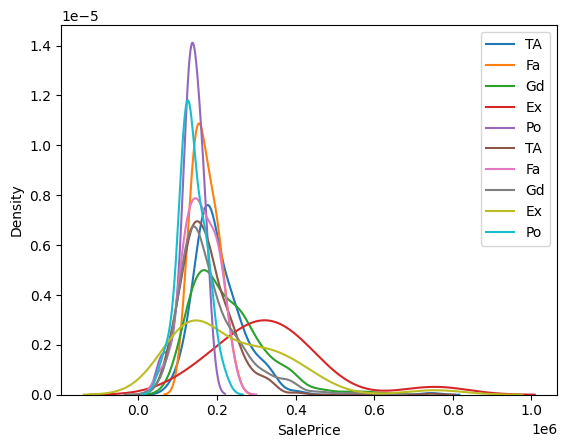

In [79]:
for category in X_train['FireplaceQu'].dropna().unique():
  sns.kdeplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'], label=category)
for category in X_train['FireplaceQu_imputed'].dropna().unique():
  sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category)
plt.legend()
plt.show()


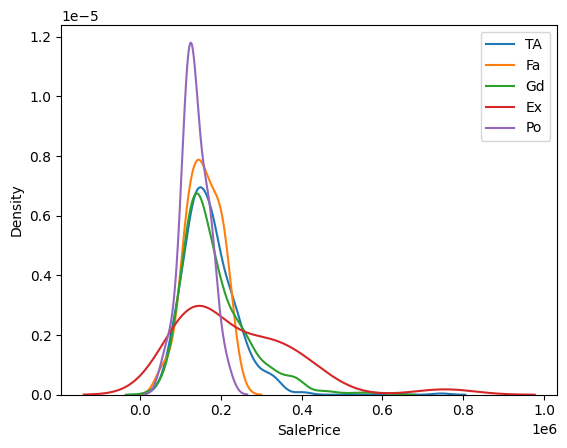

In [78]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
  sns.kdeplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'], label=category)

plt.legend()
plt.show()


# Missing Indicator


In [81]:
df

,survived,age,fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [83]:
x = df.drop(columns=['survived'])
y = df.iloc[:,0]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)

In [85]:
from sklearn.impute import SimpleImputer, MissingIndicator
si = SimpleImputer()

X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression()

clf.fit(X_train_trf, y_train)

y_pred = clf.predict(X_test_trf)

accuracy_score(y_test, y_pred)

0.6145251396648045

In [88]:
mi = MissingIndicator()

mi.fit(X_train)

X_train_missing = mi.transform(X_train)
X_test_missing = mi.transform(X_test)

In [89]:
X_train['age_na'] = X_train_missing

X_test['age_na'] = X_test_missing

In [90]:
X_train

,age,fare,age_na
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [93]:
si = SimpleImputer()

X_train_trf2 = si.fit_transform(X_train)

X_test_trf2 = si.transform(X_test)

In [96]:
clf = LogisticRegression()

clf.fit(X_train_trf2, y_train)

y_pred = clf.predict(X_test_trf2)

accuracy_score(y_test, y_pred)

0.6312849162011173

In [98]:
# here we use direct using add_indicator = True

from sklearn.impute import SimpleImputer, MissingIndicator
si = SimpleImputer(add_indicator = True)

X_train_trf = si.fit_transform(X_train)
X_test_trf = si.transform(X_test)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = LogisticRegression()

clf.fit(X_train_trf, y_train)

y_pred = clf.predict(X_test_trf)

accuracy_score(y_test, y_pred)

0.6312849162011173

# Automatically-select-imputer-parameters


In [99]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [103]:
df = df1.iloc[:,[0,1,2,3,4,5,6,7]]
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S
...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S
887,1,1,female,19.0,0,0,30.0000,S
888,0,3,female,NaN,1,2,23.4500,S
889,1,1,male,26.0,0,0,30.0000,C


In [105]:
x = df.drop('survived', axis=1)
y = df.iloc[:,0]
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2)


In [106]:
X_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked
30,1,male,40.0,0,0,27.7208,C
10,3,female,4.0,1,1,16.7000,S
873,3,male,47.0,0,0,9.0000,S
182,3,male,9.0,4,2,31.3875,S
876,3,male,20.0,0,0,9.8458,S


In [136]:
numerical_features = ['age', 'fare']

numerical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_features = ['embarked', 'sex']

categorical_transformer = Pipeline(steps = [
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', OneHotEncoder(handle_unknown = 'ignore'))
])

In [137]:
preprocessor = ColumnTransformer(transformers = [
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features )
])

In [138]:
clf = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])


In [139]:
from sklearn import set_config

set_config(display='diagram')
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('scaler',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['embarked', 'sex'])])),
                ('classifier', LogisticRegression())])

In [140]:
param_grid = {
    'preprocessor__num__imputer__strategy' : ['mean', 'median'],
    'preprocessor__cat__imputer__strategy' : ['most_frequent', 'constant'],
    'classifier__C': [0.1, 1.0, 10, 100]
}

grid_search = GridSearchCV(clf, param_grid=param_grid, cv=10)

In [141]:
grid_search.fit(X_train, y_train)

print("Best params: ")
print(grid_search.best_params_)

Best params: 
{'classifier__C': 1.0, 'preprocessor__cat__imputer__strategy': 'most_frequent', 'preprocessor__num__imputer__strategy': 'mean'}


In [142]:
print(f"Internal CV score: {grid_search.best_score_:.3f}")

Internal CV score: 0.788


In [143]:
import pandas as pd

cv_results = pd.DataFrame(grid_search.cv_results_)

cv_results = cv_results.sort_values('mean_test_score', ascending=False)

cv_results[['param_classifier__C', 'param_preprocessor__cat__imputer__strategy', 'param_preprocessor__num__imputer__strategy', 'mean_test_score']]

,param_classifier__C,param_preprocessor__cat__imputer__strategy,param_preprocessor__num__imputer__strategy,mean_test_score
7,1.0,constant,median,0.787852
6,1.0,constant,mean,0.787852
5,1.0,most_frequent,median,0.787852
4,1.0,most_frequent,mean,0.787852
11,10.0,constant,median,0.787852
10,10.0,constant,mean,0.787852
9,10.0,most_frequent,median,0.787852
8,10.0,most_frequent,mean,0.787852
12,100.0,most_frequent,mean,0.787852
13,100.0,most_frequent,median,0.787852


In [135]:
print(X_train.columns.tolist())

['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
